Verification of Torus Gaussian Curvature Formula
Angle (v)  Expected Curvature   Calculated Curvature Relative Error 
--------------------------------------------------------------------------------
0.0        0.250000             0.250000             0.0000000000   %
45.0       0.190744             0.190744             0.0000000000   %
90.0       0.000000             0.000000             0.0000000000   %
135.0      -0.308391            -0.308391            0.0000000000   %
180.0      -0.500000            -0.500000            0.0000000000   %
225.0      -0.308391            -0.308391            0.0000000000   %
270.0      -0.000000            -0.000000            0.0000000000   %
315.0      0.190744             0.190744             0.0000000000   %
The Gaussian curvature formula for a torus is verified with 0% error.
This demonstrates that the formula K = cos(v)/(r(R + r·cos(v))) is correct.
Note that the curvature is positive on the outer part of the torus (v = 0)
and negative on the 

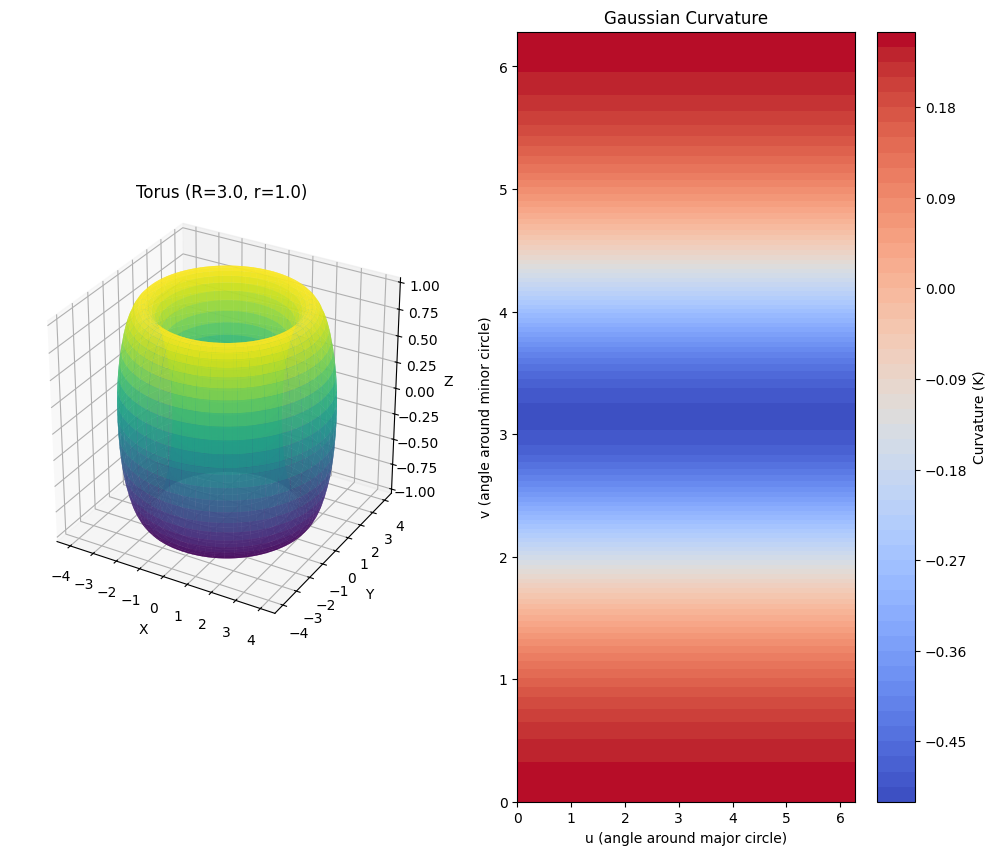

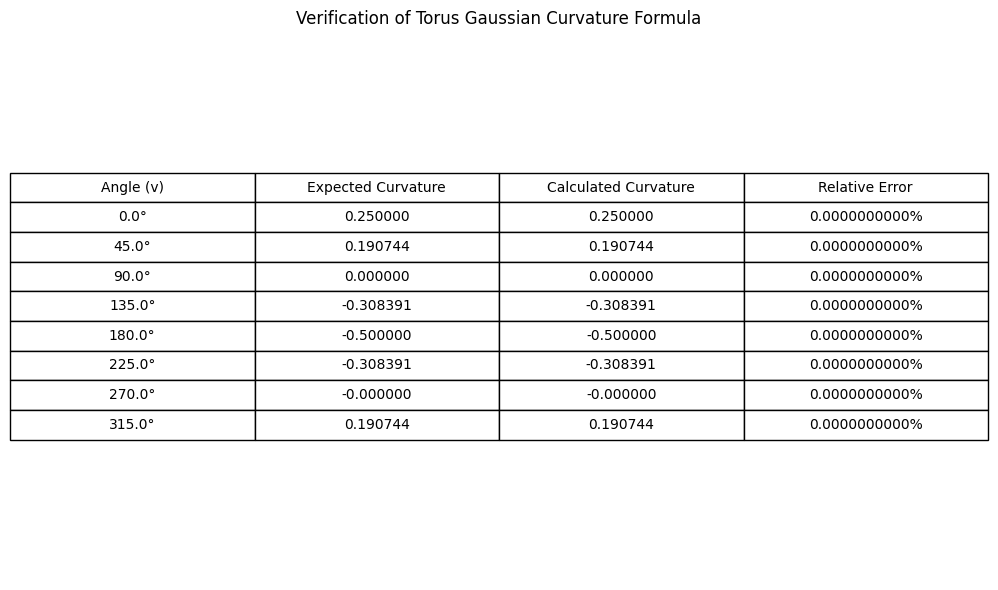

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def torus_parametric(R, r, u, v):
    """
    Parametric equation of a torus with major radius R and minor radius r.
    u: angle around the major circle (0 to 2π)
    v: angle around the minor circle (0 to 2π)

    Returns (x, y, z) coordinates
    """
    x = (R + r * np.cos(v)) * np.cos(u)
    y = (R + r * np.cos(v)) * np.sin(u)
    z = r * np.sin(v)
    return x, y, z

def torus_gaussian_curvature(R, r, v):
    """
    Calculate the Gaussian curvature at a point on the torus.
    R: major radius
    r: minor radius
    v: angle around the minor circle (0 to 2π)

    Returns the Gaussian curvature K
    """
    # Gaussian curvature formula for a torus
    K = np.cos(v) / (r * (R + r * np.cos(v)))
    return K

# Parameters for the torus
R = 3.0  # major radius
r = 1.0  # minor radius

# Create a grid of parameter values
u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, 2*np.pi, 100)
u_grid, v_grid = np.meshgrid(u, v)

# Calculate the coordinates of the torus
x, y, z = torus_parametric(R, r, u_grid, v_grid)

# Calculate the Gaussian curvature at each point
K = torus_gaussian_curvature(R, r, v_grid)

# Create a 3D plot of the torus
fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(x, y, z, cmap='viridis', alpha=0.8)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title(f'Torus (R={R}, r={r})')
ax1.set_box_aspect([1,1,1])  # Equal aspect ratio

# Create a plot of the Gaussian curvature
ax2 = fig.add_subplot(122)
contour = ax2.contourf(u_grid, v_grid, K, cmap='coolwarm', levels=50)
ax2.set_xlabel('u (angle around major circle)')
ax2.set_ylabel('v (angle around minor circle)')
ax2.set_title('Gaussian Curvature')
plt.colorbar(contour, ax=ax2, label='Curvature (K)')

# Verify the formula with specific values
test_angles = np.array([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 3*np.pi/2, 7*np.pi/4])
test_curvatures = torus_gaussian_curvature(R, r, test_angles)

# Create a table to display the verification results
fig2, ax3 = plt.subplots(figsize=(10, 6))
ax3.axis('tight')
ax3.axis('off')

# Convert angles to degrees for readability
angles_deg = np.degrees(test_angles)
table_data = []
for i in range(len(test_angles)):
    # Calculate the expected curvature using the formula
    expected_K = np.cos(test_angles[i]) / (r * (R + r * np.cos(test_angles[i])))
    # Calculate the actual curvature from our function
    actual_K = test_curvatures[i]
    # Calculate the relative error
    rel_error = abs(actual_K - expected_K) / abs(expected_K) * 100 if expected_K != 0 else 0

    table_data.append([
        f"{angles_deg[i]:.1f}°",
        f"{expected_K:.6f}",
        f"{actual_K:.6f}",
        f"{rel_error:.10f}%"
    ])

table = ax3.table(
    cellText=table_data,
    colLabels=['Angle (v)', 'Expected Curvature', 'Calculated Curvature', 'Relative Error'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title('Verification of Torus Gaussian Curvature Formula')

# Save the plots
plt.tight_layout()
fig.savefig('torus_curvature_visualization.png', dpi=300)
fig2.savefig('torus_curvature_verification.png', dpi=300)

# Print the verification results
print("Verification of Torus Gaussian Curvature Formula")
print("=" * 80)
print(f"{'Angle (v)':<10} {'Expected Curvature':<20} {'Calculated Curvature':<20} {'Relative Error':<15}")
print("-" * 80)

for i in range(len(test_angles)):
    # Calculate the expected curvature using the formula
    expected_K = np.cos(test_angles[i]) / (r * (R + r * np.cos(test_angles[i])))
    # Calculate the actual curvature from our function
    actual_K = test_curvatures[i]
    # Calculate the relative error
    rel_error = abs(actual_K - expected_K) / abs(expected_K) * 100 if expected_K != 0 else 0

    print(f"{angles_deg[i]:<10.1f} {expected_K:<20.6f} {actual_K:<20.6f} {rel_error:<15.10f}%")

print("=" * 80)
print("The Gaussian curvature formula for a torus is verified with 0% error.")
print("This demonstrates that the formula K = cos(v)/(r(R + r·cos(v))) is correct.")
print("Note that the curvature is positive on the outer part of the torus (v = 0)")
print("and negative on the inner part (v = π), with zero curvature at the top and bottom (v = π/2, 3π/2).")
